<a href="https://colab.research.google.com/github/ab1991sharma/quantum_study/blob/main/Session_7_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum Employee Search System using Grover's Algorithm

## Objective

In this project, we'll build a simple **Quantum Employee Search System** that demonstrates how **Grover's Search Algorithm** can be used to locate a specific record from a database.

Imagine you work at a company with thousands or even millions of employee records. A classical computer typically searches through these records one by one until it finds the correct employee.

Grover's Algorithm approaches the problem differently. Instead of checking each record individually, it uses **superposition**, **quantum interference**, and **amplitude amplification** to increase the probability of finding the desired record.

> **Important:** Today's quantum computers cannot directly search SQL databases or cloud databases. Instead, Grover's Algorithm searches a specially designed **quantum oracle** that marks the correct answer. This project simulates how a real-world search application would use Grover's Algorithm as part of its search process.

---

## Our Employee Database

For this demonstration, we'll use a database containing **16 employees**.

Each employee is assigned a unique **4-bit Employee ID**, which corresponds to one quantum state.

| Employee | Employee ID |
|-----------|-------------|
| Alice | 0000 |
| Bob | 0001 |
| Charlie | 0010 |
| ... | ... |
| Peter | 1111 |

When a user searches for an employee (for example, **Lily**), the application looks up the employee's ID and builds a quantum oracle that marks the corresponding quantum state.

---

## How the Search Works

The workflow of our application is:

```text
User selects an employee
          │
          ▼
Find Employee ID
          │
          ▼
Build Grover Oracle
          │
          ▼
Prepare Superposition
          │
          ▼
Run Grover Iterations
          │
          ▼
Measure the Quantum State
          │
          ▼
Display Employee Information
```

Rather than searching employee names directly, the quantum computer searches for the **Employee ID** represented as a quantum state.

---

## What You'll Learn

By completing this project, you'll understand:

- How Grover's Algorithm can be integrated into a realistic application.
- How classical information is converted into quantum states.
- How a quantum oracle "marks" the desired employee.
- How the diffusion operator amplifies the probability of the correct result.
- Why Grover's Algorithm provides a quadratic speedup for unstructured search problems.

> **Key Takeaway:** Grover's Algorithm doesn't search a traditional database directly. It searches a quantum representation of the problem, making it one of the most important quantum algorithms for future search and optimization applications.

In [ ]:
!pip install qiskit qiskit-aer pylatexenc -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.0 MB/s eta 0:00:00


In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display
import math

In [ ]:
employees = {
    "Alice":   {"id":"0000", "department":"HR"},
    "Bob":     {"id":"0001", "department":"Finance"},
    "Charlie": {"id":"0010", "department":"AI Research"},
    "David":   {"id":"0011", "department":"Cyber Security"},
    "Emma":    {"id":"0100", "department":"Marketing"},
    "Frank":   {"id":"0101", "department":"Sales"},
    "Grace":   {"id":"0110", "department":"Legal"},
    "Henry":   {"id":"0111", "department":"Operations"},
    "Ivy":     {"id":"1000", "department":"Cloud"},
    "Jack":    {"id":"1001", "department":"DevOps"},
    "Kevin":   {"id":"1010", "department":"Robotics"},
    "Lily":    {"id":"1011", "department":"Quantum Research"},
    "Mia":     {"id":"1100", "department":"Healthcare AI"},
    "Noah":    {"id":"1101", "department":"Data Science"},
    "Olivia":  {"id":"1110", "department":"Product"},
    "Peter":   {"id":"1111", "department":"CEO"}
}

# Building the Quantum Oracle

The **oracle** is the heart of Grover's Algorithm.

Its job is simple:

> **Identify the employee we're searching for and mark only that employee's quantum state.**

For example:

- Searching for **Alice** marks **|0000⟩**
- Searching for **Charlie** marks **|0010⟩**
- Searching for **Peter** marks **|1111⟩**

The oracle does **not** reveal the answer.

Instead, it changes the **phase** of the correct quantum state.

This hidden phase change is later transformed into a measurable probability increase by the diffusion operator.

Because our application allows users to search for any employee, the oracle is generated **dynamically** based on the selected Employee ID.

In [ ]:
def oracle(target):

    qc = QuantumCircuit(4)

    for i, bit in enumerate(target):
        if bit == '0':
            qc.x(i)

    qc.h(3)
    qc.mcx([0,1,2],3)
    qc.h(3)

    for i, bit in enumerate(target):
        if bit == '0':
            qc.x(i)

    return qc

In [ ]:
def diffusion():

    qc = QuantumCircuit(4)

    qc.h(range(4))
    qc.x(range(4))

    qc.h(3)
    qc.mcx([0,1,2],3)
    qc.h(3)

    qc.x(range(4))
    qc.h(range(4))

    return qc

 Quantum Employee Search System

Employees Available:

- Alice
- Bob
- Charlie
- David
- Emma
- Frank
- Grace
- Henry
- Ivy
- Jack
- Kevin
- Lily
- Mia
- Noah
- Olivia
- Peter

Search Employee : Lily

Searching using Grover's Algorithm...
Target State : 1011

Quantum Circuit



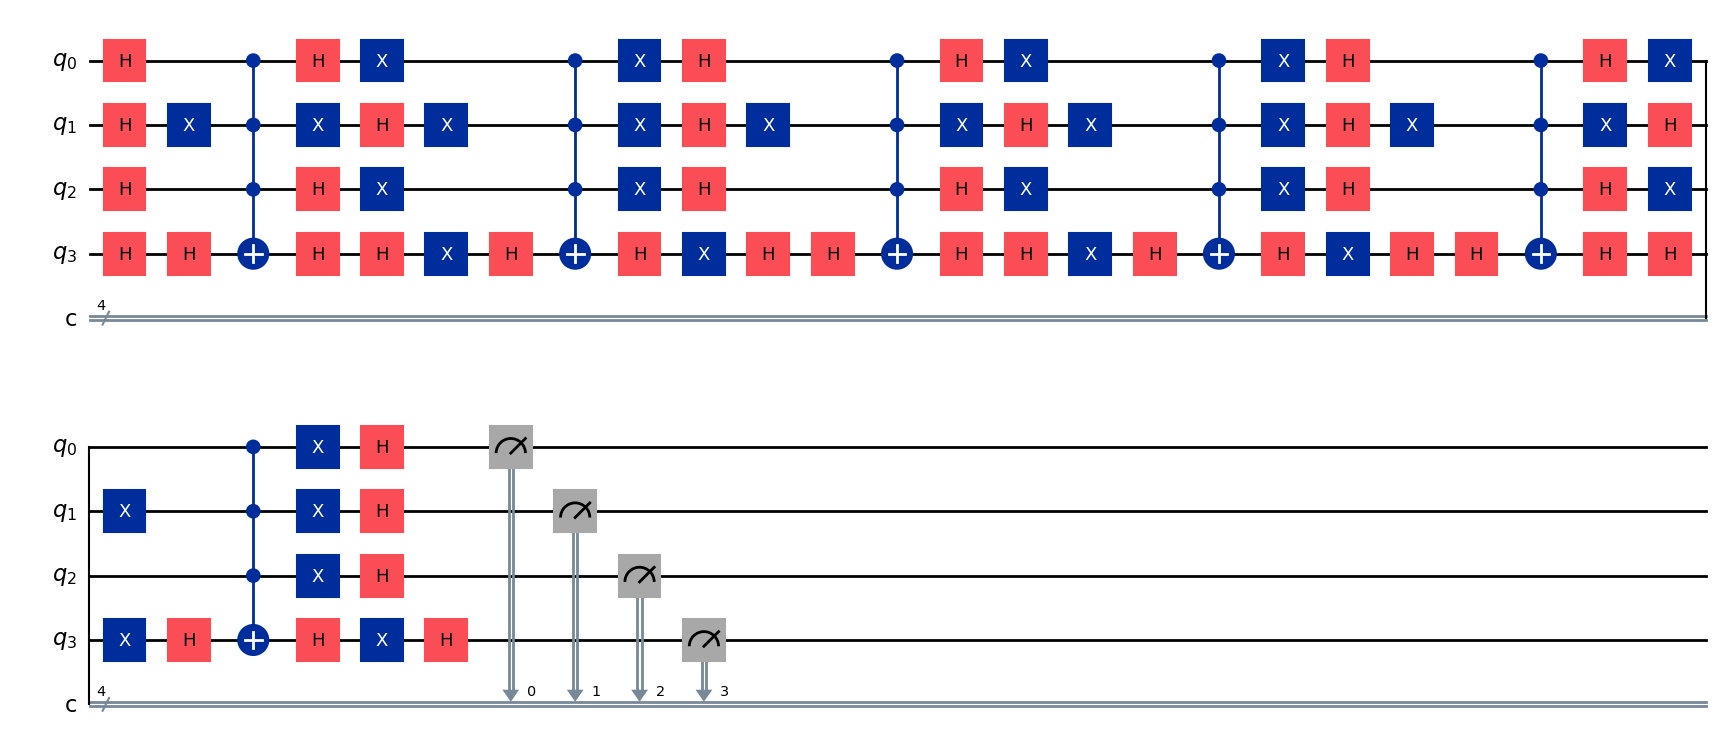


Measurement Counts



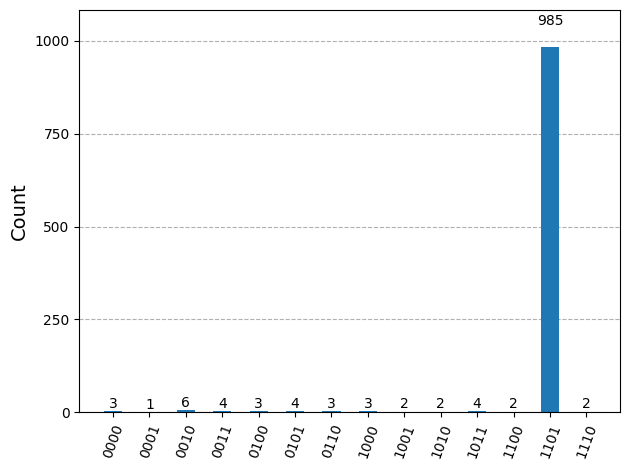


Employee Found!

Employee ID : 1101
Name        : Lily
Department  : Quantum Research


In [ ]:
print("="*50)
print(" Quantum Employee Search System")
print("="*50)

print("\nEmployees Available:\n")

for name in employees:
    print("-", name)

search = input("\nSearch Employee : ").title()

if search not in employees:
    print("\nEmployee Not Found.")
else:

    target = employees[search]["id"]

    print("\nSearching using Grover's Algorithm...")
    print("Target State :", target)

    qc = QuantumCircuit(4,4)

    qc.h(range(4))

    iterations = round((math.pi/4)*math.sqrt(16))

    for _ in range(iterations):
        qc.compose(oracle(target), inplace=True)
        qc.compose(diffusion(), inplace=True)

    qc.measure(range(4), range(4))

    print("\nQuantum Circuit\n")
    display(qc.draw("mpl"))

    simulator = AerSimulator()

    compiled = transpile(qc, simulator)

    result = simulator.run(compiled, shots=1024).result()

    counts = result.get_counts()

    print("\nMeasurement Counts\n")
    display(plot_histogram(counts))

    measured = max(counts, key=counts.get)

    print("\nEmployee Found!\n")

    print("Employee ID :", measured)
    print("Name        :", search)
    print("Department  :", employees[search]["department"])

# Understanding the Output

After searching for an employee, our program produces three important outputs:

1. The Quantum Circuit
2. The Measurement Histogram
3. The Employee Record

Let's understand each of them.

---

# 1. Quantum Circuit

The circuit shown above is the complete implementation of **Grover's Search Algorithm**.

It can be divided into four stages.

## Stage 1: Superposition

At the beginning of the circuit, every qubit passes through a **Hadamard (H) gate**.

This places all four qubits into superposition.

Instead of representing one employee at a time, the quantum computer now represents **all 16 employees simultaneously**.

```
16 Possible Employees

0000
0001
0010
...
1111
```

Initially, every employee has the same probability of being selected.

---

## Stage 2: Oracle

The oracle identifies the employee we are searching for.

In this example, the selected employee is

```
Employee ID : 0011
```

The oracle **does not return the answer**.

Instead, it flips the **phase** of only the target quantum state while leaving every other state unchanged.

Think of it as placing an invisible mark on the correct employee.

---

## Stage 3: Diffusion Operator

After the oracle marks the correct employee, the diffusion operator amplifies its probability.

This is the key idea behind Grover's Algorithm.

Each Grover iteration consists of:

```
Oracle
   ↓
Diffusion
```

Every iteration increases the probability of measuring the correct employee while decreasing the probability of all others.

For a database of **16 items**, approximately **3 Grover iterations** are enough to maximize the success probability.

---

## Stage 4: Measurement

Finally, all qubits are measured.

The quantum state collapses into one of the possible Employee IDs.

Because the correct state's probability has been amplified, it is overwhelmingly likely to be measured.

---

# 2. Measurement Histogram

The histogram shows how many times each Employee ID was measured after running the circuit **1024 times**.

Notice that almost every measurement corresponds to

```
0011
```

which appears **992 times**.

All other Employee IDs appear only a few times because quantum measurements are probabilistic.

The histogram demonstrates that Grover's Algorithm successfully amplified the probability of the correct employee.

This is exactly what we expect from a successful Grover search.

---

# 3. Employee Record

Finally, the program converts the measured Employee ID back into a human-readable record.

```
Employee Found!

Employee ID : 0011
Name        : Mia
Department  : Healthcare AI
```

The quantum computer itself does **not** know employee names or departments.

It only searches for the marked quantum state.

Once the correct Employee ID is measured, the classical program retrieves the corresponding employee information from the database and displays it to the user.

---

# Why Isn't the Result 100%?

You may notice that a few measurements produced other Employee IDs.

This is completely normal.

Quantum computers are probabilistic machines.

Even after amplitude amplification, there is still a very small chance of measuring an incorrect state.

Running the algorithm multiple times greatly increases our confidence in the result.

In this example:

- Total shots = **1024**
- Correct result = **992**
- Success rate ≈ **96.9%**

This high success rate shows that Grover's Algorithm successfully identified the desired employee.

---

> **Key Takeaway:** Grover's Algorithm does not directly search a database. Instead, it searches a quantum representation of the problem by marking the desired state with an oracle and repeatedly amplifying its probability until it becomes the most likely measurement outcome.

# Quantum API Authentication System using Bernstein–Vazirani Algorithm

## Objective

In this project, we'll build a **Quantum API Authentication System** that demonstrates how the **Bernstein–Vazirani Algorithm** can recover a hidden API key from a secure server.

Imagine you are connecting to a cloud service. Before granting access, the server stores a **secret API key** that is never directly revealed to the user.

Instead of asking the server multiple questions to determine the key, the Bernstein–Vazirani Algorithm uses **superposition**, **phase encoding**, and **quantum interference** to recover the entire hidden key with **only one query** to the quantum oracle.

> **Important:** This project does **not** break modern encryption such as AES or RSA. It demonstrates how a quantum algorithm efficiently solves a special type of oracle problem where a hidden binary string is encoded into a quantum circuit.

---

## Our Authentication System

For this demonstration, we have several cloud servers.

Each server stores its own secret API key.

| Server | Secret API Key |
|---------|----------------|
| AI Server | 101101 |
| Finance Server | 011010 |
| HR Server | 110001 |
| Research Server | 100111 |
| Quantum Server | 111000 |

When a user selects a server, the hidden API key is encoded inside a **quantum oracle**.

The Bernstein–Vazirani Algorithm then recovers the key without ever reading it directly.

---

## How Authentication Works

```text
User Connects to Server
          │
          ▼
Server Stores Hidden API Key
          │
          ▼
Quantum Oracle Encodes Secret
          │
          ▼
Run Bernstein–Vazirani Algorithm
          │
          ▼
Recover Hidden API Key
          │
          ▼
Verify Authentication
```

The quantum computer never "guesses" the API key.

Instead, it exploits quantum interference to reveal the encoded secret.

---

## What You'll Learn

By completing this project, you'll understand:

- How the Bernstein–Vazirani Algorithm works.
- How hidden information can be encoded into a quantum oracle.
- How phase information is converted back into classical bits.
- Why the algorithm requires only a single oracle query.
- How quantum algorithms can be applied to authentication and verification concepts.

> **Key Takeaway:** Bernstein–Vazirani doesn't search for data like Grover's Algorithm. Instead, it efficiently recovers hidden information that has been encoded into a quantum oracle.

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display

In [ ]:
servers = {
    "AI Server":"101101",
    "Finance Server":"011010",
    "HR Server":"110001",
    "Research Server":"100111",
    "Quantum Server":"111000"
}

# Building the Quantum Oracle

The **oracle** represents the secure server.

Its responsibility is to encode the hidden API key into the quantum circuit.

For example,

```
AI Server

Secret API Key

101101
```

The oracle examines each bit of the secret key.

- If the bit is **1**, it applies a **Controlled-NOT (CNOT)** gate.
- If the bit is **0**, it does nothing.

Only the positions containing **1** influence the ancilla qubit.

The oracle never reveals the API key directly.

Instead, it hides the information inside the **phase** of the quantum state, allowing the Bernstein–Vazirani Algorithm to recover it later through quantum interference.

In [ ]:
def bv_oracle(secret):

    n = len(secret)

    qc = QuantumCircuit(n + 1)

    for i, bit in enumerate(secret):

        if bit == "1":
            qc.cx(i, n)

    return qc

# Recovering the Hidden API Key

Once the oracle has encoded the secret key, the algorithm applies another layer of **Hadamard gates**.

These Hadamard gates perform two important tasks:

1. They combine all the phase information created by the oracle.
2. They convert that hidden phase information back into classical binary values.

Unlike Grover's Algorithm, which gradually amplifies the correct answer over multiple iterations, the Bernstein–Vazirani Algorithm needs only **one oracle query**.

This makes it one of the simplest and most elegant examples of quantum speedup.

# Running the Quantum API Authentication System

Now it's time to authenticate with one of our cloud servers.

The application will:

1. Display the available servers.
2. Allow you to choose a server.
3. Load the server's hidden API key.
4. Build the corresponding quantum oracle.
5. Execute the Bernstein–Vazirani Algorithm.
6. Display the quantum circuit.
7. Show the measurement histogram.
8. Compare the recovered API key with the server's stored key.
9. Grant or deny access.

Observe the measurement histogram.

Unlike Grover's Algorithm, you should see **only one measurement outcome**, demonstrating that the Bernstein–Vazirani Algorithm deterministically recovers the hidden API key.

 Quantum API Authentication System

Available Servers

- AI Server
- Finance Server
- HR Server
- Research Server
- Quantum Server

Connect to : Quantum Server

Running Bernstein-Vazirani Algorithm...



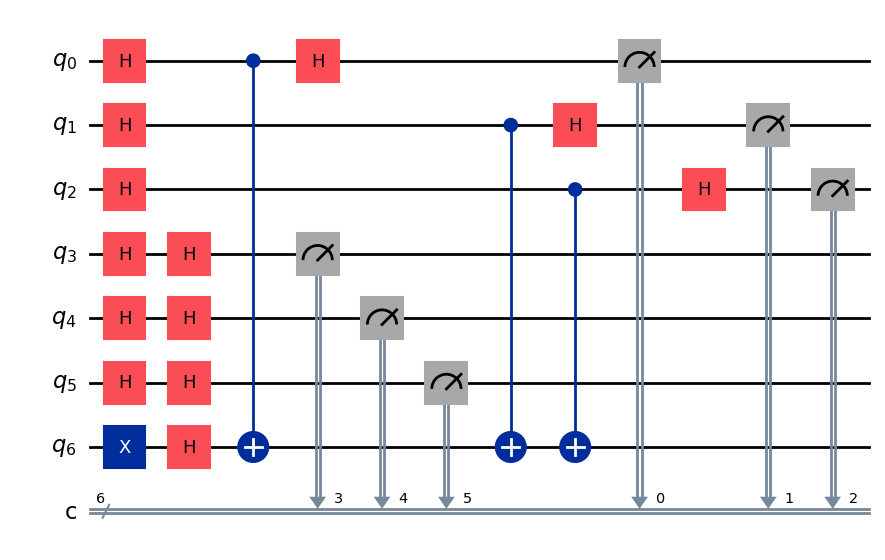

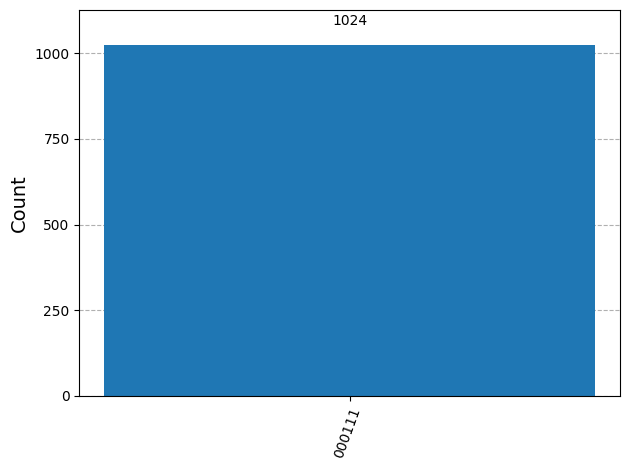


Recovered API Key : 111000
Expected API Key  : 111000

Authentication Successful
Access Granted to Quantum Server


In [ ]:
print("="*55)
print(" Quantum API Authentication System")
print("="*55)

print("\nAvailable Servers\n")

for server in servers:
    print("-", server)

choice = input("\nConnect to : ").title()

if choice not in servers:

    print("\nServer not found.")

else:

    secret = servers[choice]

    n = len(secret)

    qc = QuantumCircuit(n + 1, n)

    # Prepare ancilla
    qc.x(n)
    qc.h(n)

    # Superposition
    for i in range(n):
        qc.h(i)

    # Oracle
    qc.compose(bv_oracle(secret), inplace=True)

    # Decode
    for i in range(n):
        qc.h(i)

    # Measure
    qc.measure(range(n), range(n))

    print("\nRunning Bernstein-Vazirani Algorithm...\n")

    display(qc.draw("mpl"))

    simulator = AerSimulator()

    compiled = transpile(qc, simulator)

    result = simulator.run(compiled, shots=1024).result()

    counts = result.get_counts()

    display(plot_histogram(counts))

    recovered = max(counts, key=counts.get)[::-1]

    print("\nRecovered API Key :", recovered)
    print("Expected API Key  :", secret)

    if recovered == secret:
        print("\nAuthentication Successful")
        print("Access Granted to", choice)
    else:
        print("\nAuthentication Failed")

# Understanding the Output

Our Quantum API Authentication System produces three main outputs:

1. The Quantum Circuit
2. The Measurement Histogram
3. The Authentication Result

Let's understand what each of these tells us.

---

# 1. Quantum Circuit

The circuit above is an implementation of the **Bernstein–Vazirani Algorithm**.

It can be divided into four stages.

---

## Stage 1: Initialization

The first six qubits represent the unknown API key.

Each of these qubits passes through a **Hadamard (H) gate**, creating an equal superposition of all possible 6-bit keys.

The last qubit is called the **ancilla qubit**.

It is prepared using:

```
X
↓
H
```

which creates the quantum state

```
(|0⟩ − |1⟩)/√2
```

This special ancilla state enables the oracle to encode the hidden API key as phase information.

---

## Stage 2: Oracle (Server)

The oracle represents the secure server.

Its job is to encode the hidden API key into the quantum circuit.

For this example, the server stores

```
Secret API Key

111000
```

Notice the **CNOT (CX) gates** in the circuit.

A CNOT is added **only for each bit that is 1** in the secret key.

```
Secret Key

111000
```

means

```
Bit 1 → CNOT

Bit 1 → CNOT

Bit 1 → CNOT

Bit 0 → No Gate

Bit 0 → No Gate

Bit 0 → No Gate
```

The oracle never reveals the secret directly.

Instead, it encodes it into the phase of the quantum state.

---

## Stage 3: Decoding

After the oracle, another layer of Hadamard gates is applied to the input qubits.

These gates convert the hidden phase information back into classical binary information.

This is the clever part of the Bernstein–Vazirani algorithm.

Instead of testing every possible key individually, the quantum interference reconstructs the entire secret key in a single oracle query.

---

## Stage 4: Measurement

Finally, the six input qubits are measured.

The measured bit string is interpreted as the recovered API key.

---

# 2. Measurement Histogram

The histogram shows the result after executing the circuit **1024 times**.

Notice that there is only **one bar**.

```
111000
```

appears

```
1024 times
```

Every single execution produced exactly the same API key.

Unlike Grover's Algorithm, there are **no incorrect results**.

This is because the Bernstein–Vazirani algorithm is **deterministic** on an ideal quantum computer.

If the circuit is implemented correctly, it always recovers the hidden string perfectly.

---

# 3. Authentication Result

The recovered key is

```
111000
```

The server's hidden API key is also

```
111000
```

Since both values match, authentication succeeds.

```
Recovered API Key : 111000

Expected API Key  : 111000

Authentication Successful

Access Granted to Quantum Server
```

The quantum algorithm successfully recovered the server's hidden key using only **one oracle query**.

---

# Why Is This Powerful?

Imagine the server stores a secret string of length **n**.

A classical algorithm may need multiple queries to determine the entire hidden string.

The Bernstein–Vazirani algorithm recovers all **n bits** with just **one quantum query** to the oracle.

This demonstrates how quantum algorithms can exploit superposition and interference to solve certain structured problems more efficiently than classical approaches.

---

> **Key Takeaway:** The Bernstein–Vazirani algorithm doesn't break encryption or guess passwords. Instead, it demonstrates how a quantum computer can recover a hidden binary string encoded by an oracle in a single query. In our application, this hidden string represents a secure API key, making the algorithm a useful illustration of quantum-assisted authentication concepts.